# Bottleneck Deconv Training - Weighted MSE Loss
Training ComplexBottleneckDeconvDecoder with BottleneckEncoder using weighted MSE loss from weightMatrix.nii

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
from tqdm.auto import tqdm
import nibabel as nib

# Runtime reload
import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckAE,
)
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


## Define Weighted Loss Function

In [2]:
class WeightedMSELoss(nn.Module):
    def __init__(self, weight_mask_path, target_shape=None):
        super().__init__()
        # Load weight mask
        weight_nii = nib.load(weight_mask_path)
        weight_data = weight_nii.get_fdata()
        
        # Convert to tensor
        weight_tensor = torch.from_numpy(weight_data).float()
        
        # Resize if target shape is provided
        if target_shape is not None:
            print(f"Resizing weight mask from {weight_tensor.shape} to {target_shape}")
            weight_tensor = weight_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
            weight_tensor = F.interpolate(
                weight_tensor, 
                size=target_shape, 
                mode='trilinear', 
                align_corners=False
            )
            weight_tensor = weight_tensor.squeeze(0).squeeze(0)
        
        # Add batch/channel dimensions
        self.weight_mask = weight_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
        
        # Normalize weights to have mean 1 for stable loss scaling
        self.weight_mask = self.weight_mask / self.weight_mask.mean()
        
        print(f"Weight mask shape: {self.weight_mask.shape}")
        print(f"Weight range: [{self.weight_mask.min():.4f}, {self.weight_mask.max():.4f}]")
    
    def forward(self, pred, target):
        # Move mask to same device as predictions
        if self.weight_mask.device != pred.device:
            self.weight_mask = self.weight_mask.to(pred.device)
        
        # Resize mask if needed to match prediction shape
        if self.weight_mask.shape[2:] != pred.shape[2:]:
            resized_mask = F.interpolate(
                self.weight_mask,
                size=pred.shape[2:],
                mode='trilinear',
                align_corners=False
            )
        else:
            resized_mask = self.weight_mask
        
        # Compute weighted MSE
        squared_error = (pred - target) ** 2
        weighted_error = squared_error * resized_mask
        return weighted_error.mean()

In [3]:
# Create weighted loss criterion with target shape
criterion = WeightedMSELoss("data/masks/weightMatrix.nii", target_shape=(64, 128, 128))
print("Weighted MSE loss criterion created")

Resizing weight mask from torch.Size([91, 109, 91]) to (64, 128, 128)
Weight mask shape: torch.Size([1, 1, 64, 128, 128])
Weight range: [0.2699, 5.5536]
Weighted MSE loss criterion created


## Data Setup

In [4]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/BottleneckDeconvWeightedTraining"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [5]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=2
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [6]:
target_shape = (64, 128, 128)

def build_model(latent_dim=128):
    """Build ComplexBottleneckDeconvDecoder model"""
    model = BottleneckAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
    )
    return model.to(device)

def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 10
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True
    return config

## Training All Latent Dimensions with Weighted Loss


[1/5] ================== Training deconv_weighted_lat256 ==================

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 13.32M
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat256/deconv_weighted_lat256_checkpoint.pth
No checkpoint found at output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat256/deconv_weighted_lat256_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/150|Train]:   0%|                                                                | 0/89250 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/150


Progress [E1/150|Val]:   1%|▎                                                     | 595/89250 [00:32<1:12:56, 20.26it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0


...

Epoch 142/150 | Train: 0.007304 | Val: 0.008728 | LR: 0.00000625 | ETA: 5.20m

GPU Memory Usage:
Allocated: 464.16 MB
Cached: 490.00 MB
CPU Memory Usage: 2145.94 MB
Early stopping counter: 8/10
DEBUG: Starting epoch 143/150


Progress [E144/150|Train]:  95%|█████████████████████████████████████████████▊  | 85085/89250 [1:32:55<03:22, 20.61it/s]

Epoch 143/150 | Train: 0.007300 | Val: 0.008716 | LR: 0.00000625 | ETA: 4.55m

GPU Memory Usage:
Allocated: 464.16 MB
Cached: 490.00 MB
CPU Memory Usage: 2145.94 MB
Early stopping counter: 9/10
DEBUG: Starting epoch 144/150


Progress [E144/150|Val]:  96%|████████████████████████████████████████████████  | 85680/89250 [1:34:11<03:55, 15.16it/s]

Epoch 144/150 | Train: 0.007299 | Val: 0.008697 | LR: 0.00000625 | ETA: 3.92m

GPU Memory Usage:
Allocated: 464.16 MB
Cached: 490.00 MB
CPU Memory Usage: 2145.94 MB
Early stopping counter: 10/10
Early stopping triggered. Best epoch was 133.

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat256/deconv_weighted_lat256_training_history.png


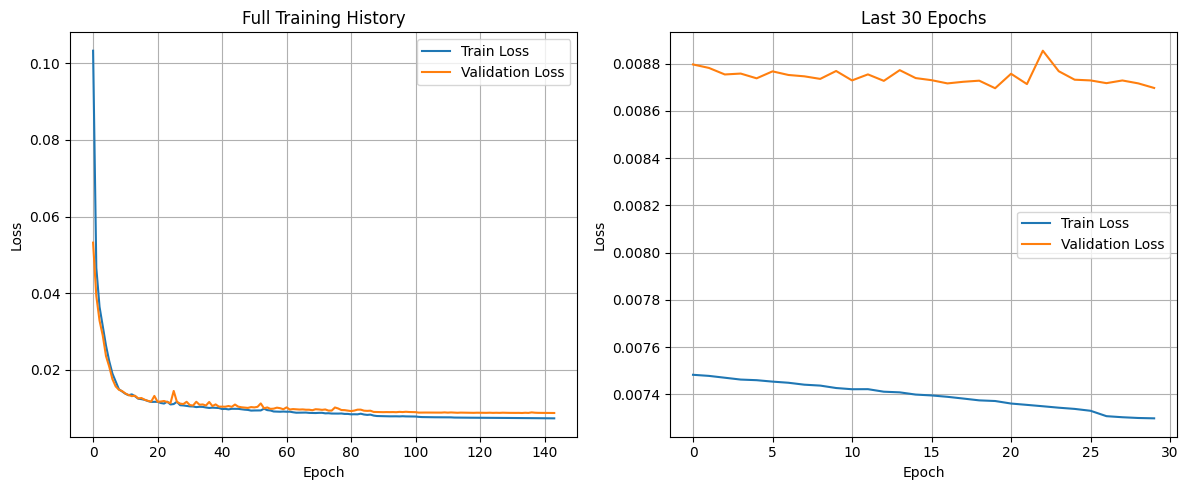

DEBUG: Plot saved and displayed successfully

Training completed in 94.19 minutes
Best validation loss: 0.008696
✓ Completed in 5651.6s | Time/Epoch: 37.68s | Final Val Loss: 0.008697


In [17]:
# Latent dimensions to test
deconv_latent_dims = [512, 256, 128, 64, 32]
weighted_histories = {}
weighted_results = []

num_epochs = 150

for idx, latent_dim in enumerate(deconv_latent_dims[1:2]):
    model_name = f"deconv_weighted_lat{latent_dim}"
    print(f"\n[{idx+1}/{len(deconv_latent_dims)}] ================== Training {model_name} ==================")
    
    cfg = create_training_config(model_name, num_epochs)
    model = build_model(latent_dim=latent_dim)
    
    # Count parameters
    num_params = count_trainable(model)
    print(f"Parameters: {num_params / 1e6:.2f}M")
    
    # Time the training
    start_time = time.time()
    
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=criterion,  # Use weighted MSE loss
    )
    
    elapsed_time = time.time() - start_time
    time_per_epoch = elapsed_time / num_epochs
    
    weighted_histories[model_name] = {"train": train_losses, "val": val_losses}
    weighted_results.append({
        "Model": model_name,
        "Latent Dim": latent_dim,
        "Parameters": num_params,
        "Final Val Loss": val_losses[-1],
        "Best Val Loss": min(val_losses),
        "Final Train Loss": train_losses[-1],
        "Total Time (s)": elapsed_time,
        "Time per Epoch (s)": time_per_epoch,
    })
    
    print(f"✓ Completed in {elapsed_time:.1f}s | Time/Epoch: {time_per_epoch:.2f}s | Final Val Loss: {val_losses[-1]:.6f}")

In [18]:
weighted_results

[{'Model': 'deconv_weighted_lat256',
  'Latent Dim': 256,
  'Parameters': 13320589,
  'Final Val Loss': 0.008696617827369463,
  'Best Val Loss': 0.00869550870656467,
  'Final Train Loss': 0.007298970329692634,
  'Total Time (s)': 5651.602779626846,
  'Time per Epoch (s)': 37.67735186417897}]

## Results Summary

In [8]:
# Create results dataframe
weighted_results_df = pd.DataFrame(weighted_results)
display(weighted_results_df)

# Save results
weighted_results_df.to_csv(os.path.join(output_dir, "weighted_training_results.csv"), index=False)
print(f"\nResults saved to {os.path.join(output_dir, 'weighted_training_results.csv')}")

,Model,Latent Dim,Parameters,Final Val Loss,Best Val Loss,Final Train Loss,Total Time (s),Time per Epoch (s)
0,deconv_weighted_lat512,512,25903757,0.008420,0.008402,0.006617,3772.244723,25.148298
1,deconv_weighted_lat256,256,13320589,0.014165,0.014135,0.013380,5274.835442,35.165570
2,deconv_weighted_lat128,128,7029005,0.009014,0.009009,0.008023,5082.470944,33.883140
3,deconv_weighted_lat64,64,3883213,0.009270,0.009264,0.008585,4207.153085,28.047687
4,deconv_weighted_lat32,32,2310317,0.009730,0.009689,0.009021,4813.397701,32.089318



Results saved to output/Experiments/BottleneckDeconvWeightedTraining/weighted_training_results.csv


## Visualization

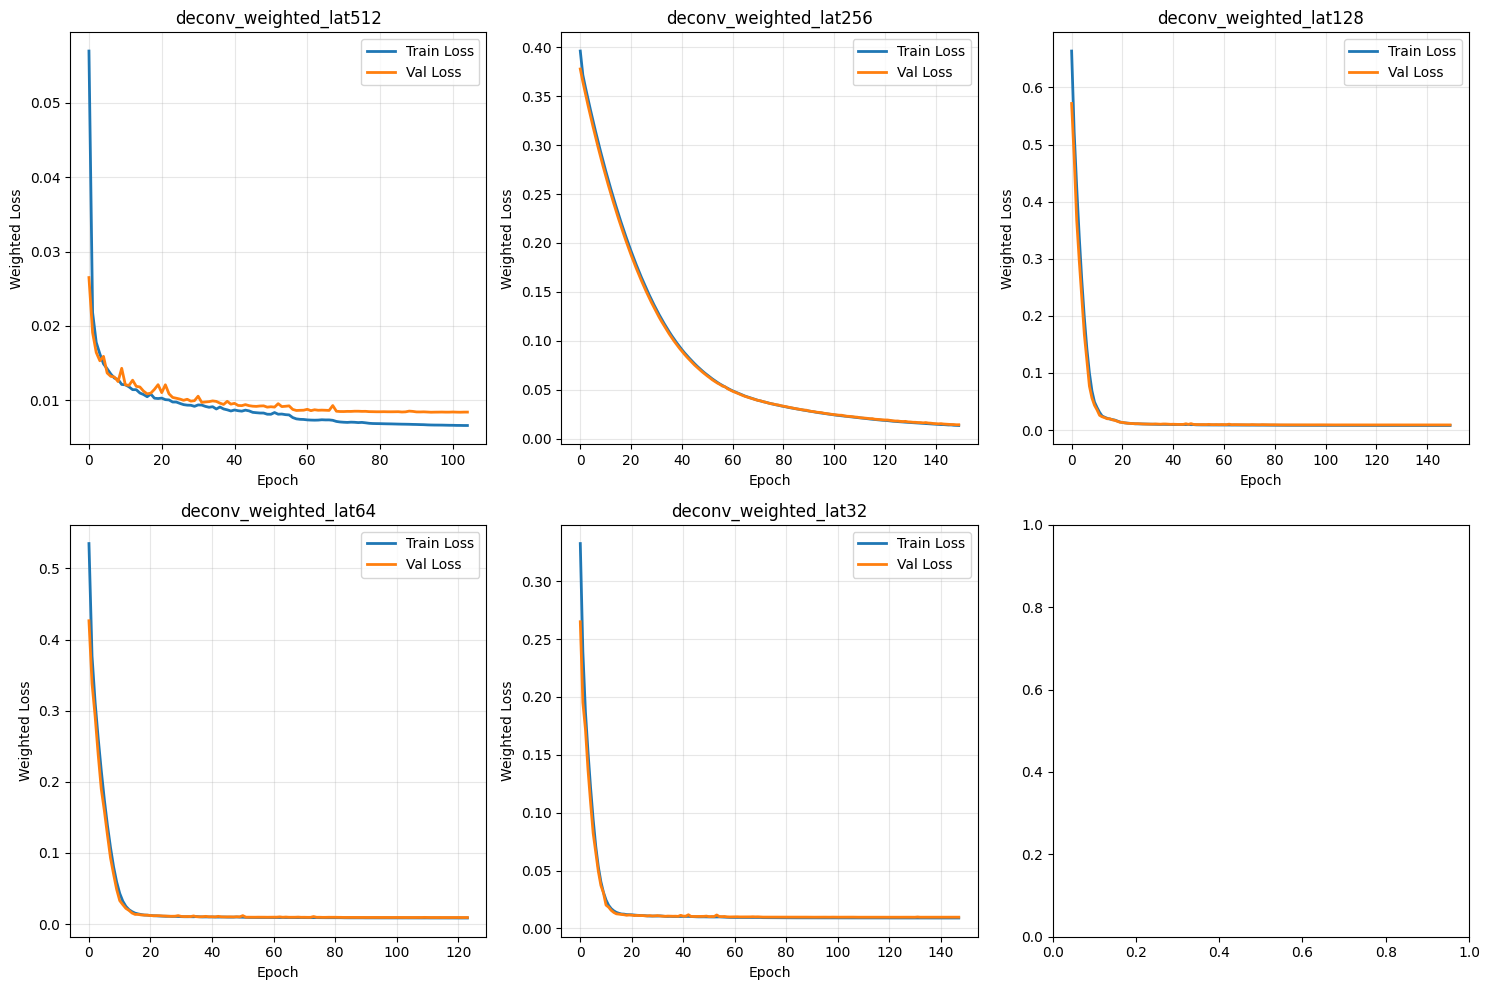

Training curves saved to output/Experiments/BottleneckDeconvWeightedTraining/weighted_training_curves.png


In [9]:
# Plot training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, history) in enumerate(weighted_histories.items()):
    ax = axes[idx]
    ax.plot(history['train'], label='Train Loss', linewidth=2)
    ax.plot(history['val'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Weighted Loss')
    ax.set_title(model_name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "weighted_training_curves.png"), dpi=150)
plt.show()

print(f"Training curves saved to {os.path.join(output_dir, 'weighted_training_curves.png')}")

In [20]:
weighted_results_df = pd.read_csv('output/Experiments/BottleneckDeconvWeightedTraining/weighted_training_results.csv')

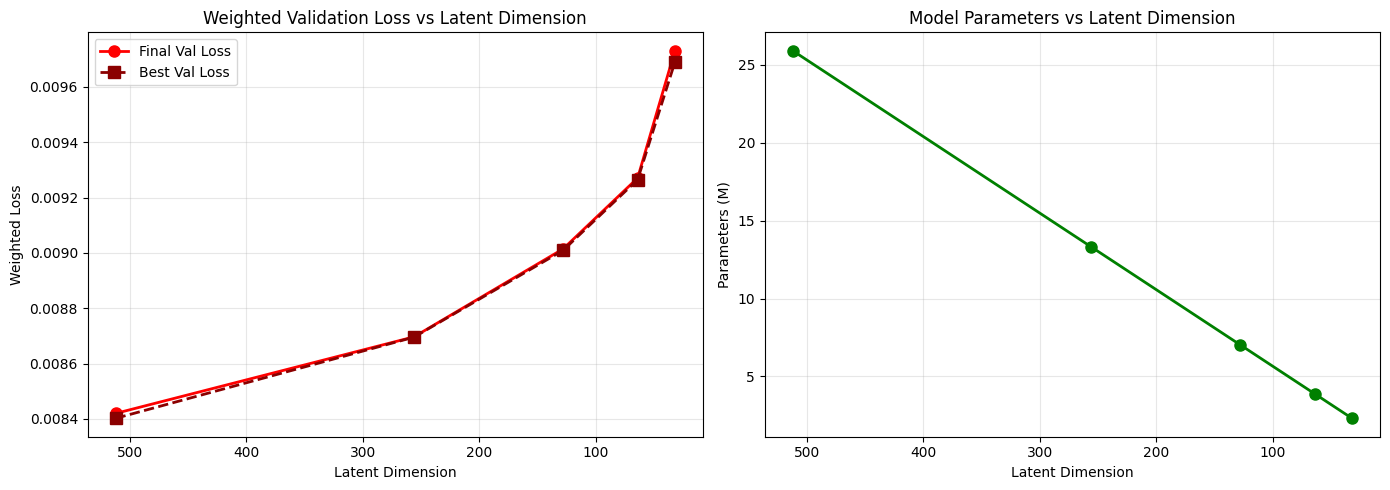

Comparison analysis saved to output/Experiments/BottleneckDeconvWeightedTraining/weighted_comparison_analysis.png


In [21]:
# Compare final losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Final validation loss vs latent dim
latent_dims = weighted_results_df['Latent Dim'].values
final_val_losses = weighted_results_df['Final Val Loss'].values
best_val_losses = weighted_results_df['Best Val Loss'].values

axes[0].plot(latent_dims, final_val_losses, 'o-', label='Final Val Loss', linewidth=2, markersize=8, color='red')
axes[0].plot(latent_dims, best_val_losses, 's--', label='Best Val Loss', linewidth=2, markersize=8, color='darkred')
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('Weighted Loss')
axes[0].set_title('Weighted Validation Loss vs Latent Dimension')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()

# Parameters vs latent dim
params = weighted_results_df['Parameters'].values / 1e6
axes[1].plot(latent_dims, params, 'o-', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Parameters (M)')
axes[1].set_title('Model Parameters vs Latent Dimension')
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "weighted_comparison_analysis.png"), dpi=150)
plt.show()

print(f"Comparison analysis saved to {os.path.join(output_dir, 'weighted_comparison_analysis.png')}")

## Comparison: Weighted vs Unweighted
If you have results from the unweighted training, compare them here

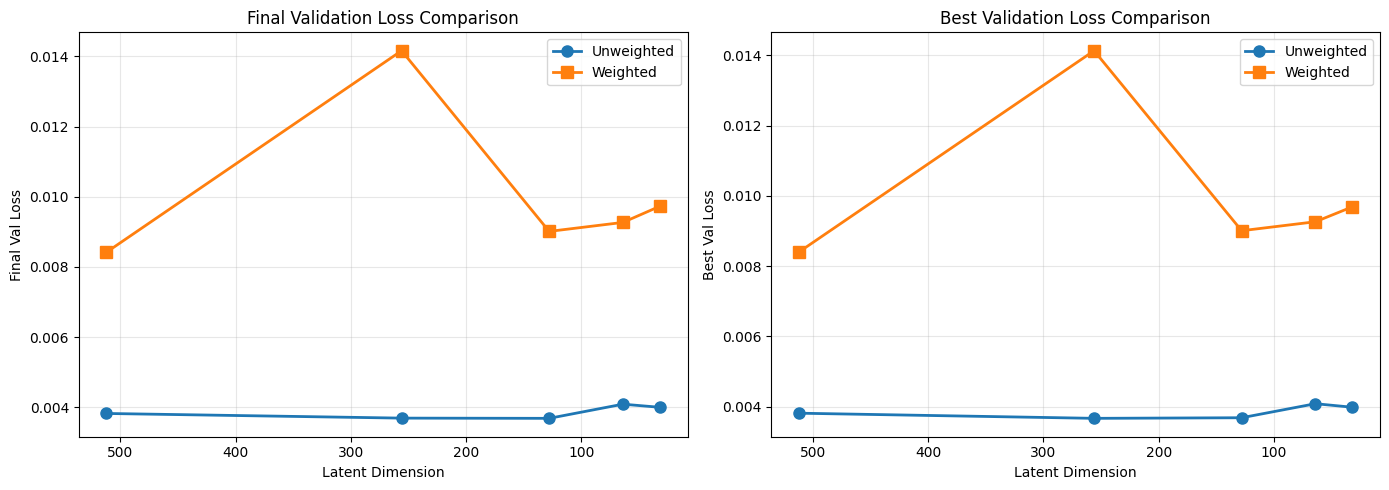

Comparison plot saved


In [11]:
# Optional: Load unweighted results if available and compare
unweighted_results_path = "output/Experiments/BottleneckDeconvTraining/training_results.csv"

try:
    unweighted_df = pd.read_csv(unweighted_results_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sort by latent dim for proper plotting
    unweighted_sorted = unweighted_df.sort_values('Latent Dim', ascending=False)
    weighted_sorted = weighted_results_df.sort_values('Latent Dim', ascending=False)
    
    latent_dims = unweighted_sorted['Latent Dim'].values
    
    # Compare final validation losses
    axes[0].plot(latent_dims, unweighted_sorted['Final Val Loss'].values, 'o-', label='Unweighted', linewidth=2, markersize=8)
    axes[0].plot(latent_dims, weighted_sorted['Final Val Loss'].values, 's-', label='Weighted', linewidth=2, markersize=8)
    axes[0].set_xlabel('Latent Dimension')
    axes[0].set_ylabel('Final Val Loss')
    axes[0].set_title('Final Validation Loss Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].invert_xaxis()
    
    # Compare best validation losses
    axes[1].plot(latent_dims, unweighted_sorted['Best Val Loss'].values, 'o-', label='Unweighted', linewidth=2, markersize=8)
    axes[1].plot(latent_dims, weighted_sorted['Best Val Loss'].values, 's-', label='Weighted', linewidth=2, markersize=8)
    axes[1].set_xlabel('Latent Dimension')
    axes[1].set_ylabel('Best Val Loss')
    axes[1].set_title('Best Validation Loss Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].invert_xaxis()
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "weighted_vs_unweighted_comparison.png"), dpi=150)
    plt.show()
    
    print("Comparison plot saved")
except FileNotFoundError:
    print(f"Unweighted results not found at {unweighted_results_path}")
    print("Run the unweighted training notebook first to enable comparison")

In [22]:
# Load all trained models from checkpoints
trained_weighted_models = {}
deconv_latent_dims = [512, 256, 128, 64, 32]

for latent_dim in deconv_latent_dims:
    model_name = f"deconv_weighted_lat{latent_dim}"
    checkpoint_path = os.path.join(output_dir, model_name, f"{model_name}_best.pth")
    
    if os.path.exists(checkpoint_path):
        print(f"Loading {model_name} from {checkpoint_path}...")
        model = build_model(latent_dim=latent_dim)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        trained_weighted_models[model_name] = model.eval()
        print(f"✓ Loaded {model_name}")
    else:
        print(f"✗ Checkpoint not found for {model_name}")

print(f"\nLoaded {len(trained_weighted_models)} models")

Loading deconv_weighted_lat512 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat512/deconv_weighted_lat512_best.pth...
✓ Loaded deconv_weighted_lat512
Loading deconv_weighted_lat256 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat256/deconv_weighted_lat256_best.pth...
✓ Loaded deconv_weighted_lat256
Loading deconv_weighted_lat128 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat128/deconv_weighted_lat128_best.pth...
✓ Loaded deconv_weighted_lat128
Loading deconv_weighted_lat64 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat64/deconv_weighted_lat64_best.pth...
✓ Loaded deconv_weighted_lat64
Loading deconv_weighted_lat32 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat32/deconv_weighted_lat32_best.pth...
✓ Loaded deconv_weighted_lat32

Loaded 5 models


In [32]:
valIterator = (iter(val_loader))

In [36]:
# Get a batch for reconstruction visualization
batch = next(valIterator)
inp = batch['volume'].to(device)
labels = batch['label']

print(f"Input batch shape: {inp.shape}")
print(f"Labels: {labels}")

# Get reconstructions from all models
weighted_reconstructions = {}
with torch.no_grad():
    for model_name, model in trained_weighted_models.items():
        out = model(inp)
        weighted_reconstructions[model_name] = out

Input batch shape: torch.Size([4, 1, 64, 128, 128])
Labels: ['Control', 'PD', 'PD', 'PD']


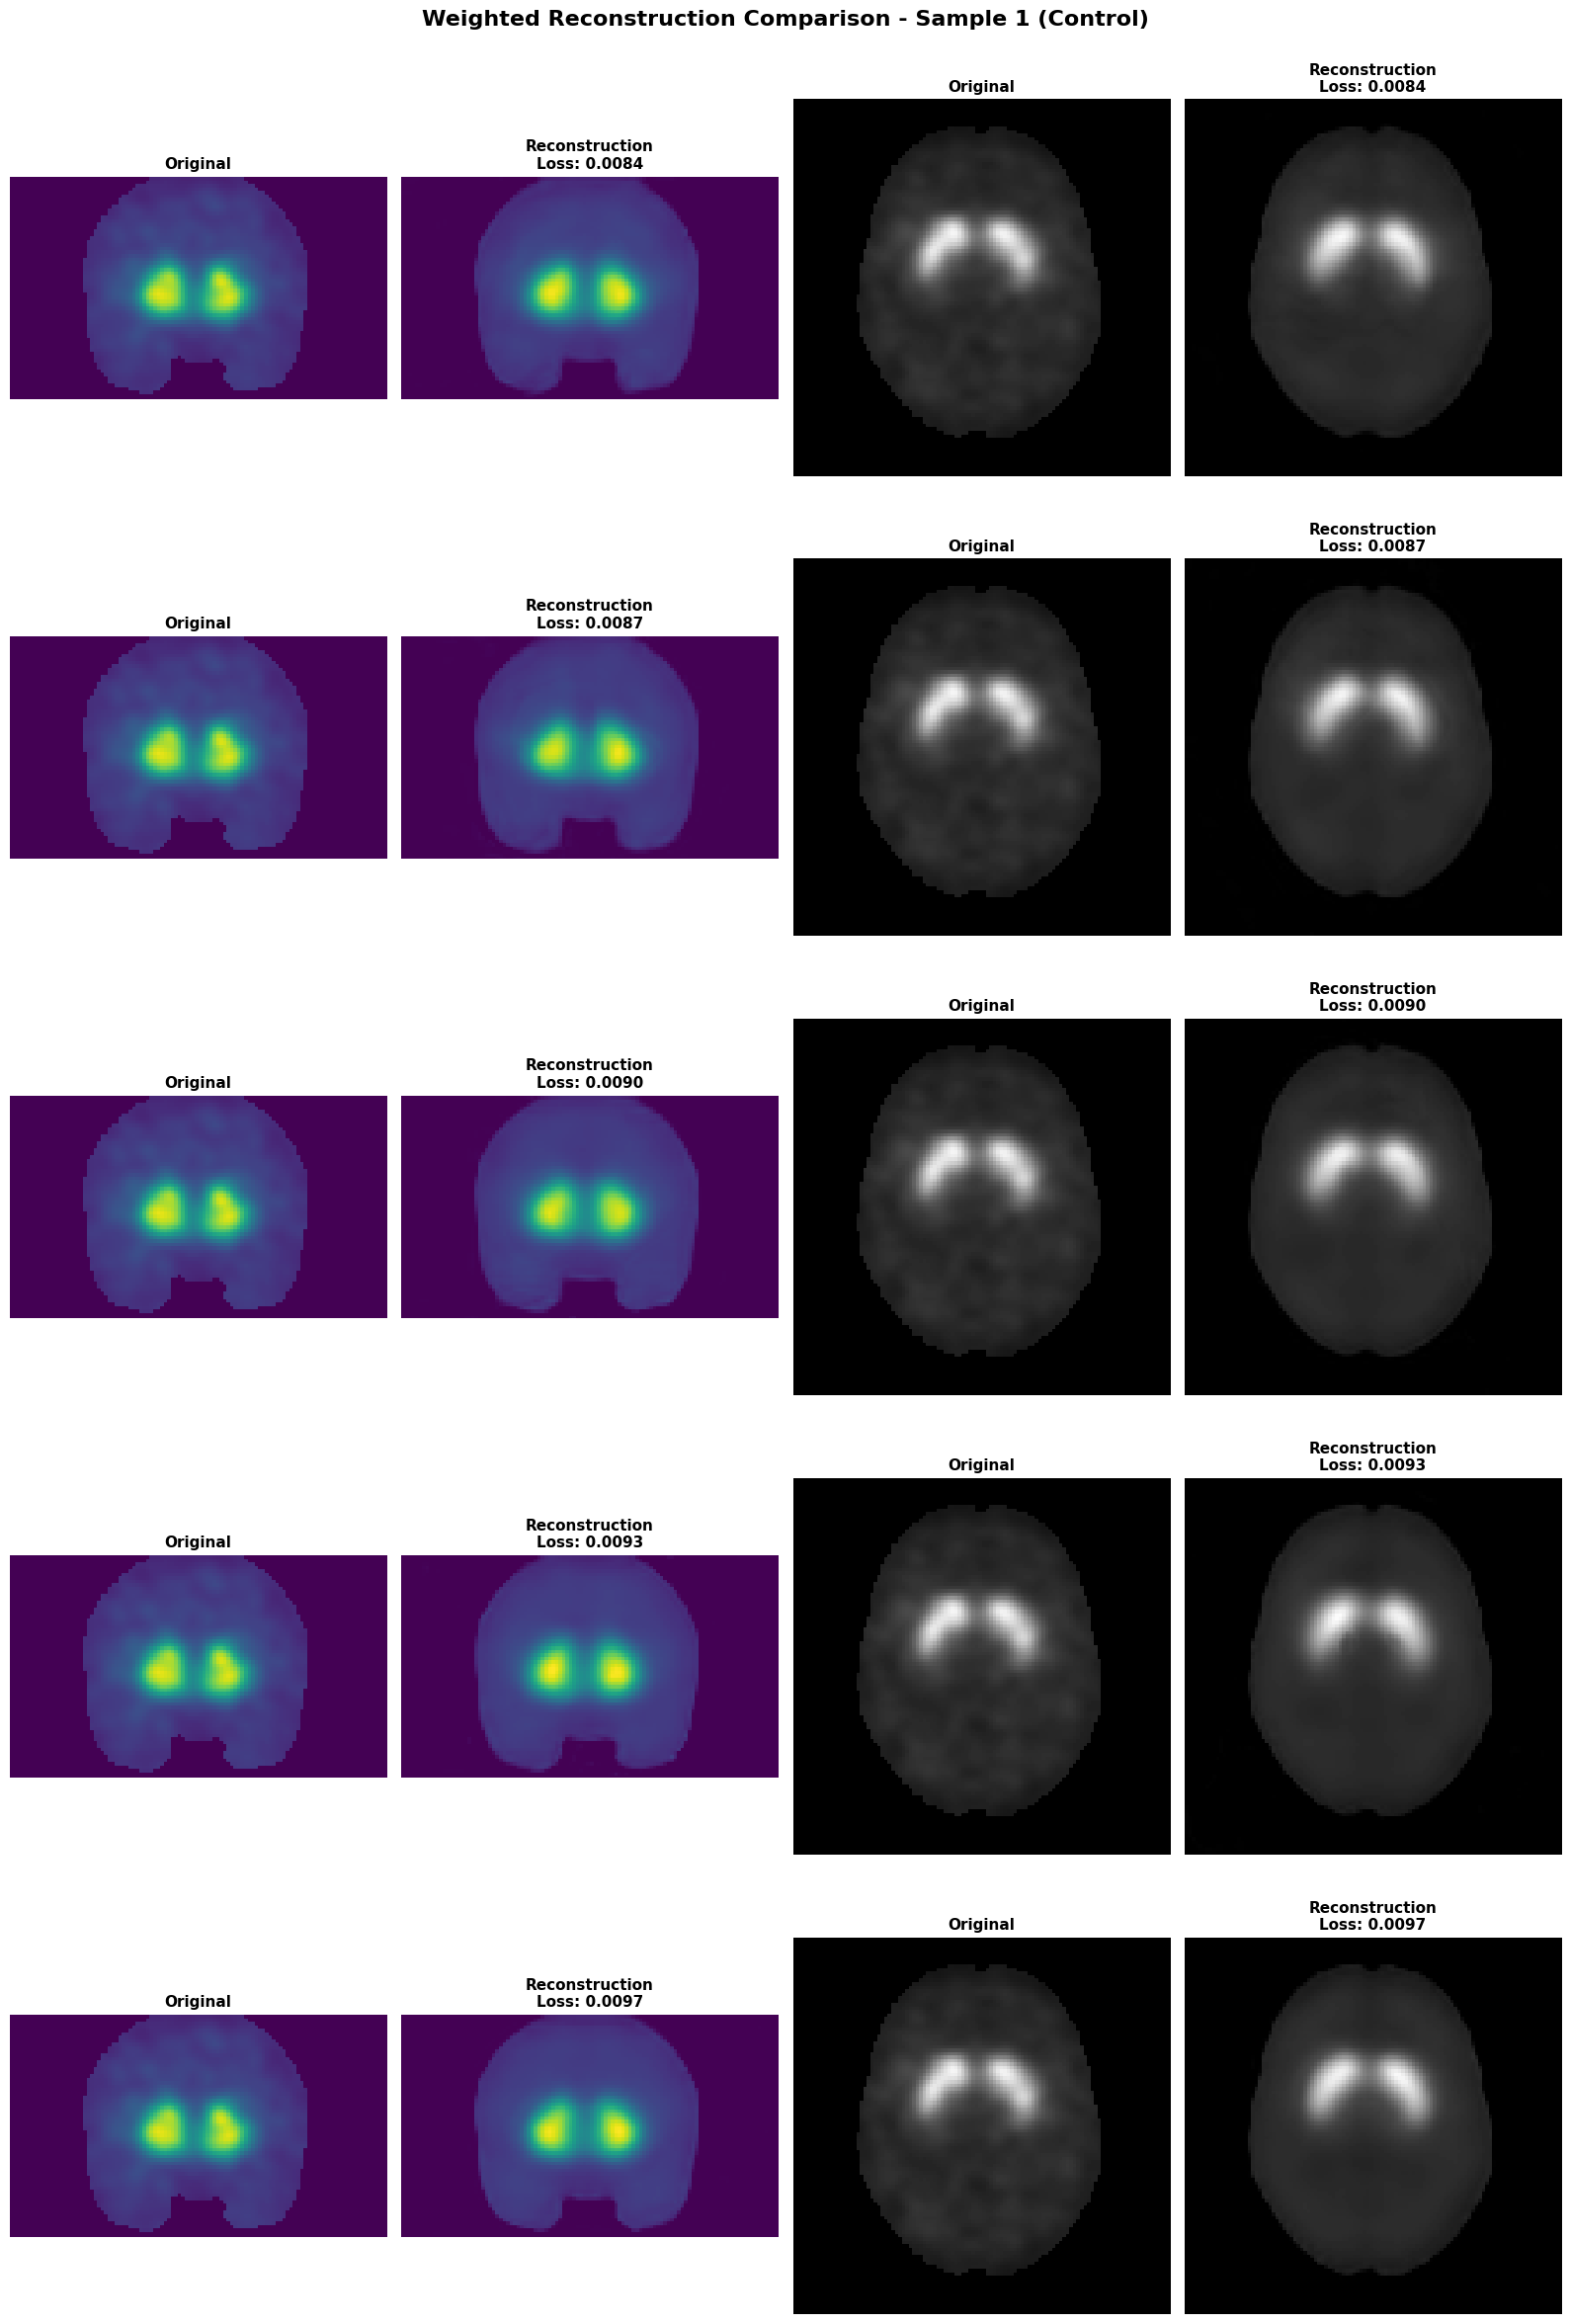

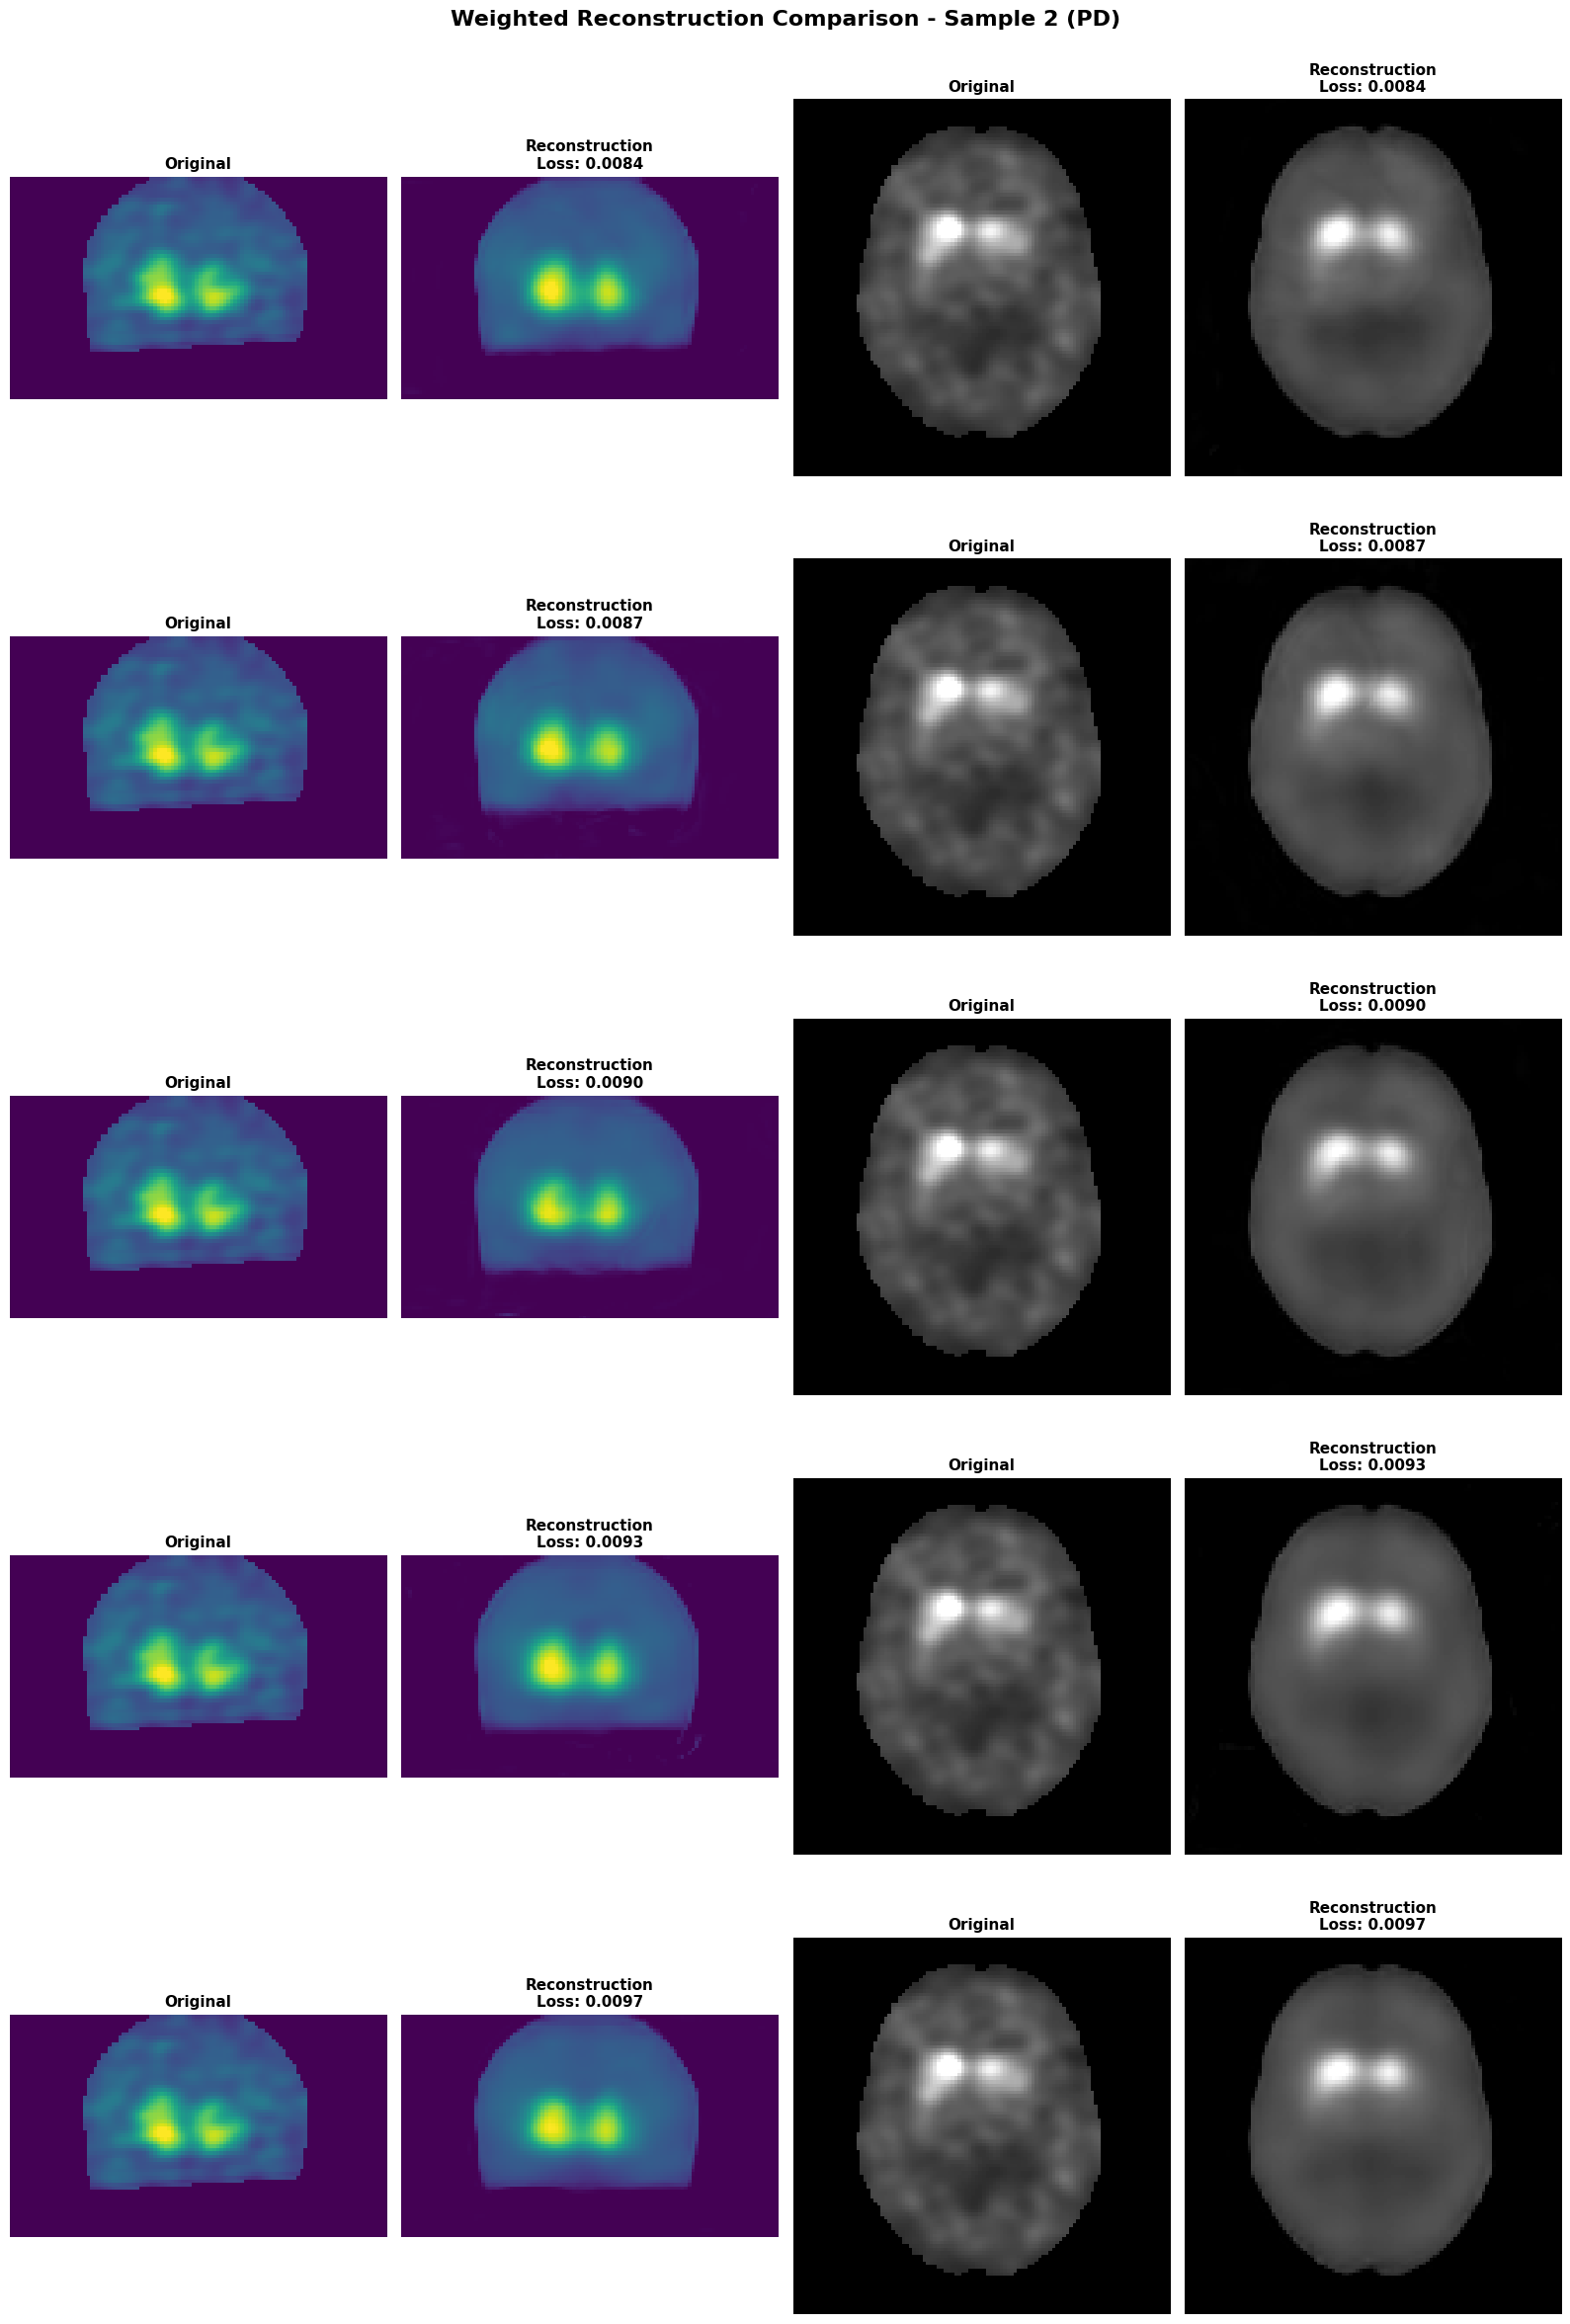

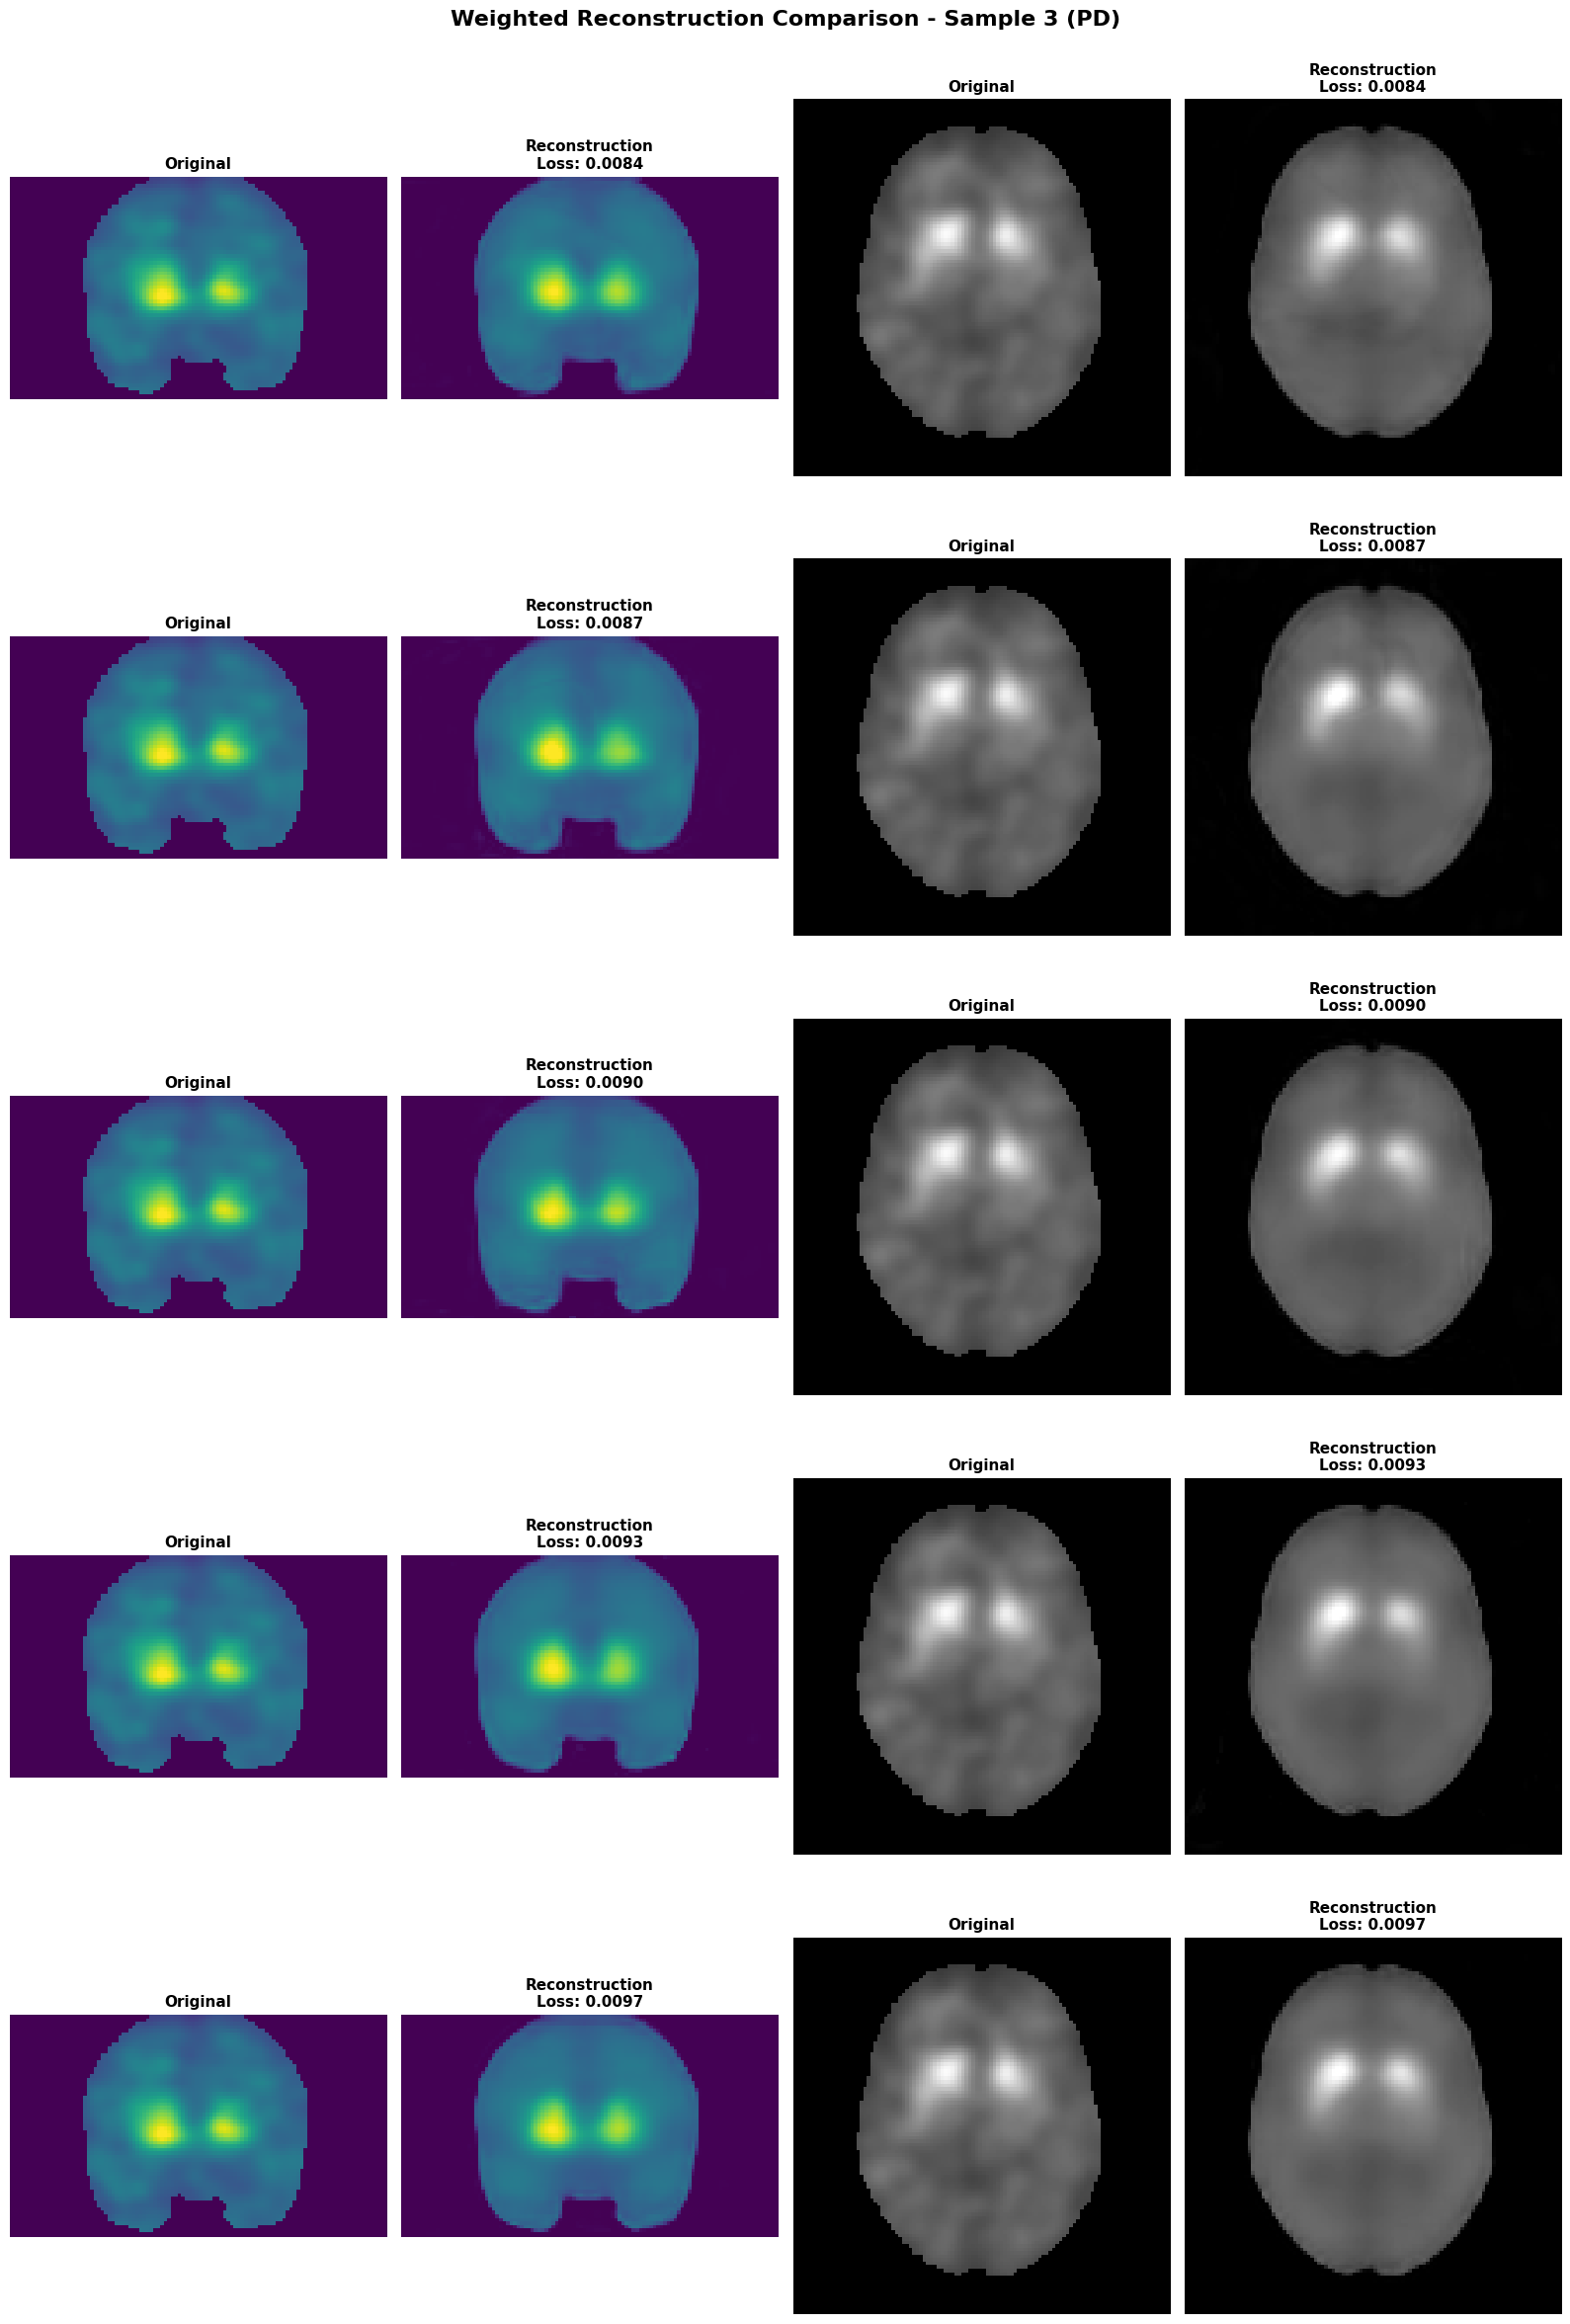

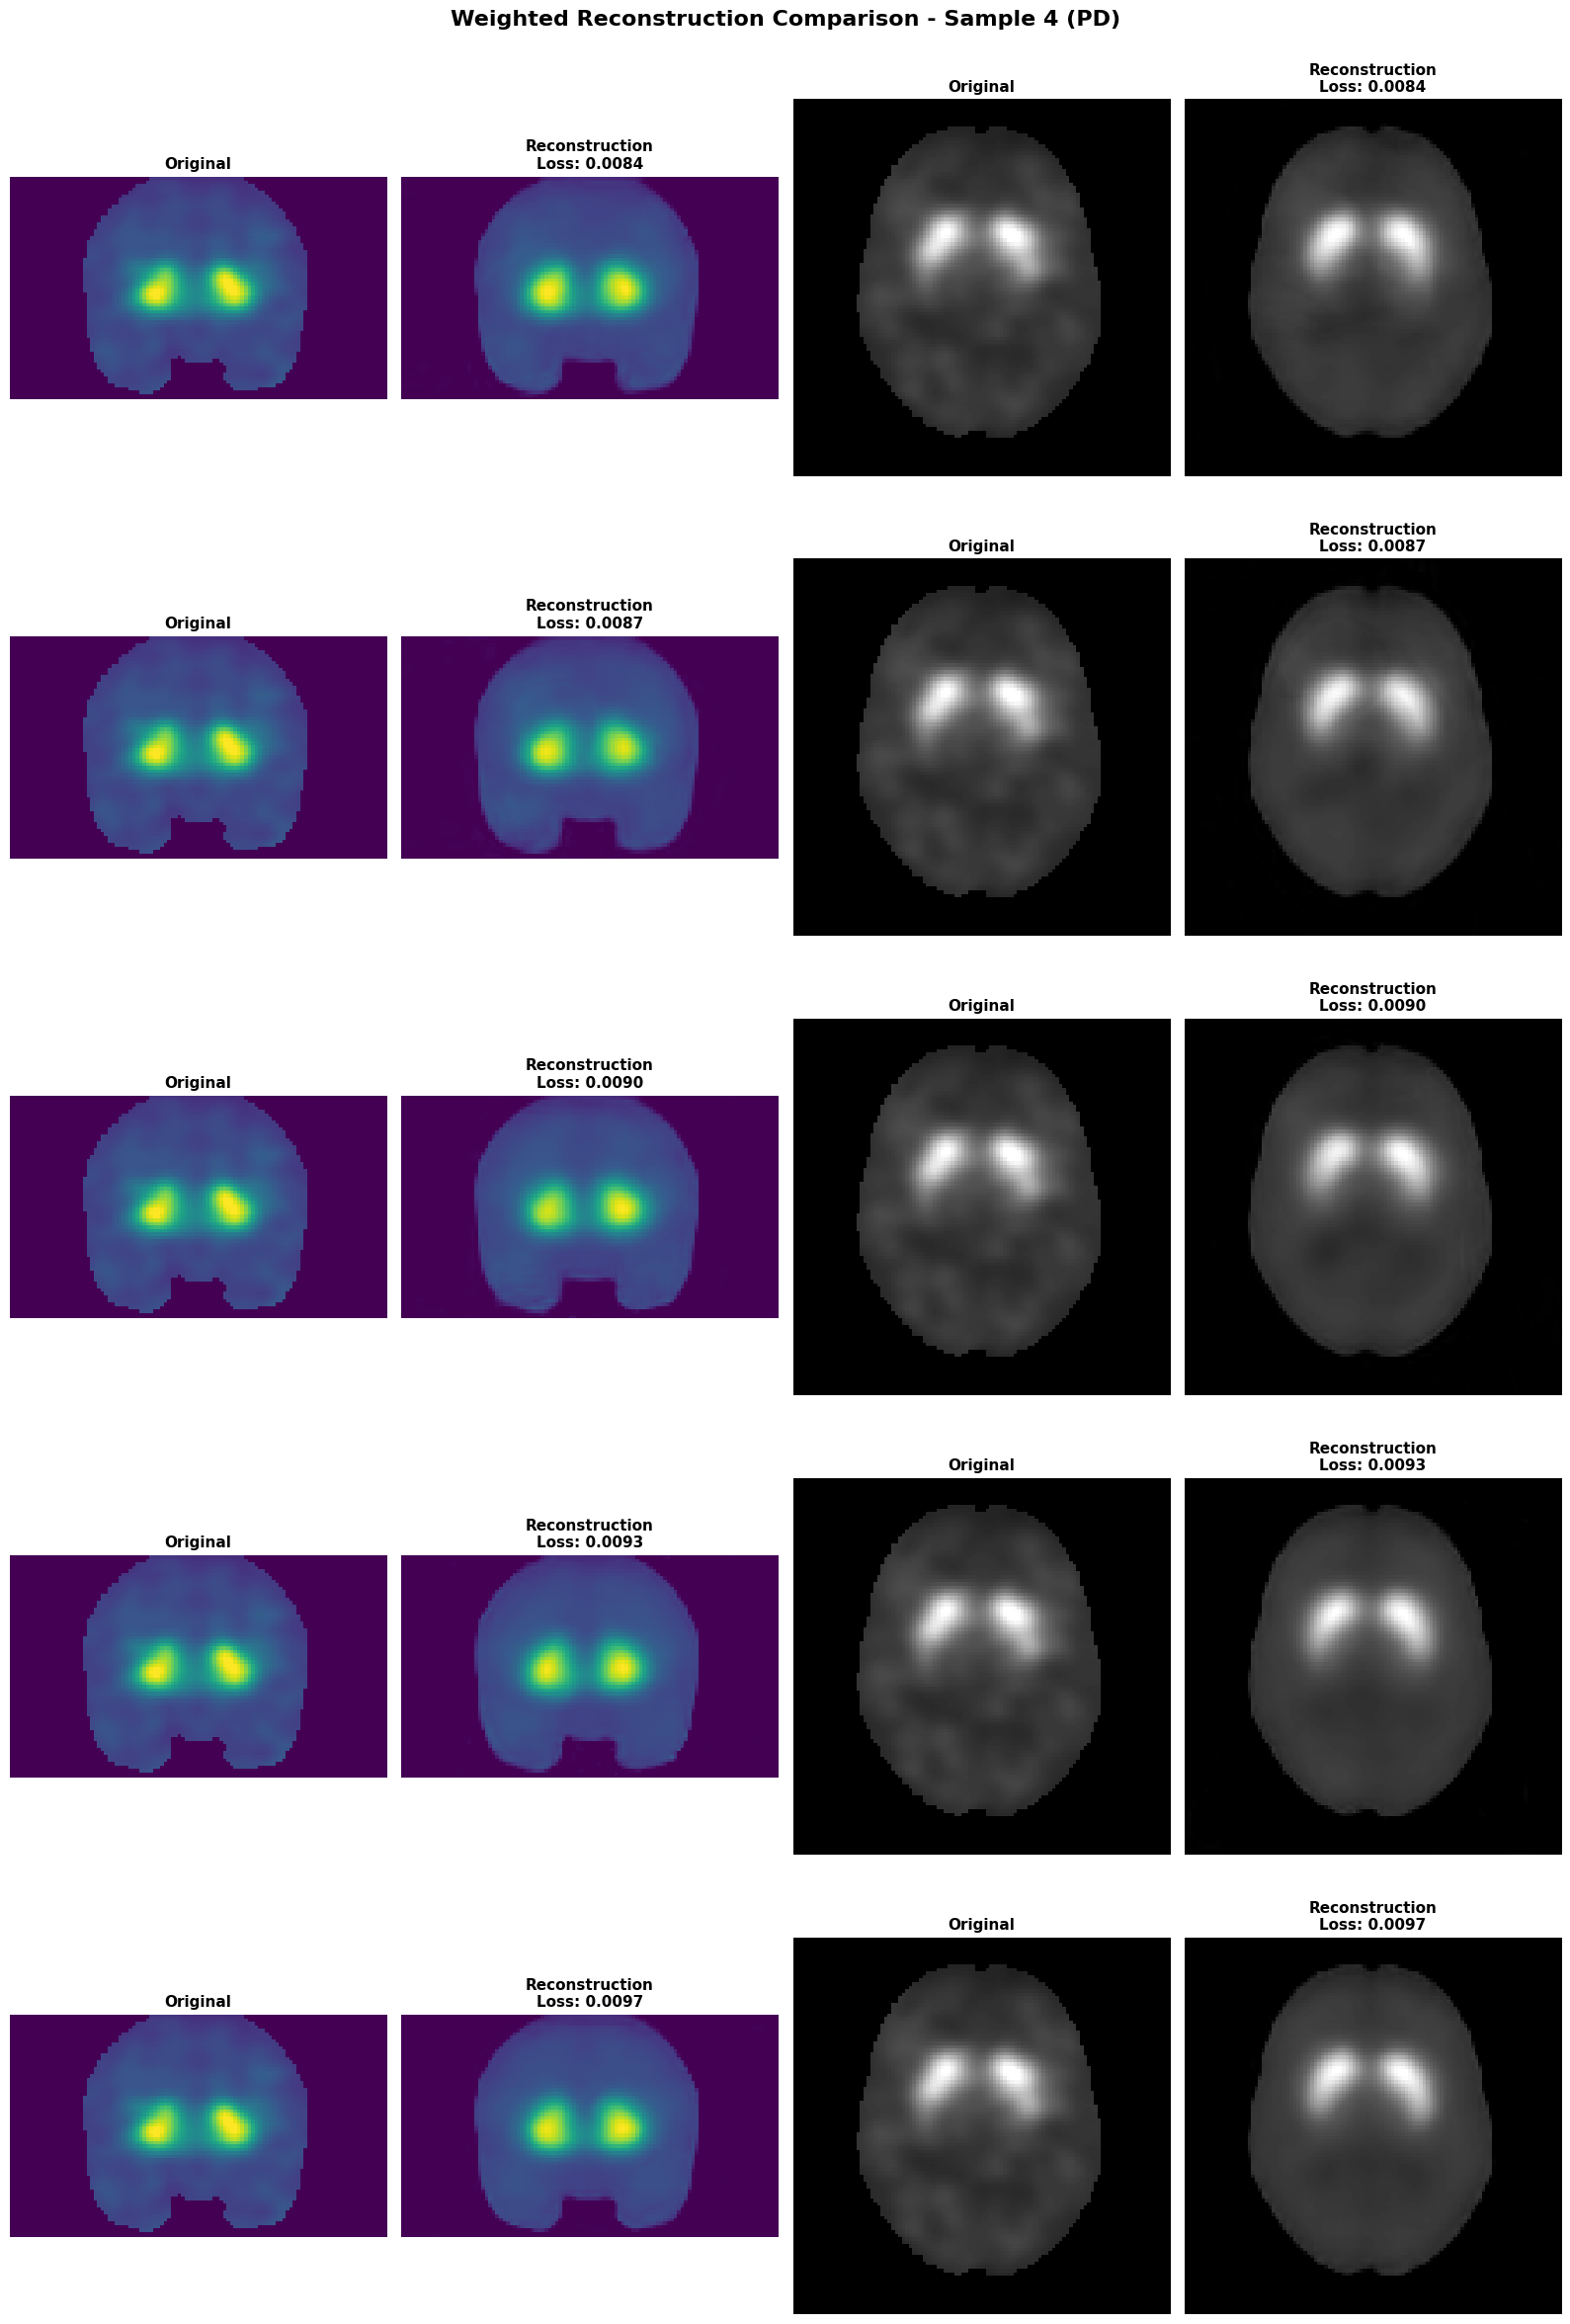

Weighted reconstruction visualizations saved to output/Experiments/BottleneckDeconvWeightedTraining


In [38]:
# Visualize reconstructions for each sample in batch
for pIdx in range(min(4, inp.shape[0])):
    fig = plt.figure(figsize=(16, 24))
    vmax = recon[pIdx,0,:,50,10:-10].cpu().max()
    # Loop through each latent dimension
    for row_idx, latent_dim in enumerate(deconv_latent_dims):
        model_name = f"deconv_weighted_lat{latent_dim}"
        recon = weighted_reconstructions[model_name]
        val_loss = weighted_results_df[weighted_results_df['Latent Dim'] == int(latent_dim)]['Final Val Loss'].values[0]
        
        # Original image - Sagittal view
        ax = plt.subplot(len(deconv_latent_dims), 4, row_idx * 4 + 1)
        ax.imshow(inp[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=vmax)
        ax.set_ylim(0, 64)
        ax.set_ylabel(f"Lat Dim: {latent_dim}\nSagittal", fontsize=12, fontweight='bold')
        ax.set_title("Original", fontsize=11, fontweight='bold')
        ax.axis('off')
        
        # Reconstruction - Sagittal view
        ax = plt.subplot(len(deconv_latent_dims), 4, row_idx * 4 + 2)
        ax.imshow(recon[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=vmax)
        ax.set_ylim(0, 64)
        ax.set_title(f"Reconstruction\nLoss: {val_loss:.4f}", fontsize=11, fontweight='bold')
        ax.axis('off')
        
        # Original image - Axial view
        ax = plt.subplot(len(deconv_latent_dims), 4, row_idx * 4 + 3)
        ax.imshow(inp[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=vmax)
        ax.set_title("Original", fontsize=11, fontweight='bold')
        ax.axis('off')
        
        # Reconstruction - Axial view
        ax = plt.subplot(len(deconv_latent_dims), 4, row_idx * 4 + 4)
        ax.imshow(recon[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=vmax)
        ax.set_title(f"Reconstruction\nLoss: {val_loss:.4f}", fontsize=11, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle(f"Weighted Reconstruction Comparison - Sample {pIdx + 1} ({labels[pIdx]})", fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"weighted_reconstruction_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Weighted reconstruction visualizations saved to {output_dir}")